# USD Rates RV — Regression, beta-stability & cointegration

Showcases `RVUtils.regression` (fair-value vs drivers, beta-stability TLI, residual diagnostics) and `RVUtils.cointegration` (Engle-Granger / Johansen) on USD swap & UST data.

In [1]:
%matplotlib inline
import sys; sys.path.append("../../")
import datetime, pytz, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (15, 6); plt.rcParams["axes.grid"] = True
from RVUtils.plt_timeseries import make_secondary_axis_plot

NYC = pytz.timezone("America/New_York")
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP
from TB.FixedRateBondsTB import FixedRateBondsTB
from Query.Unified.UnifiedQuery import UnifiedQuery
from Query.Unified.registry import UnifiedValue
from TB.TimeseriesBuilder import TimeseriesBuilder

curve_mdp = IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC")
usts_mdp = FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-RL")
ts = TimeseriesBuilder()
start = NYC.localize(datetime.datetime(2025, 6, 2, 17, 0))
end = NYC.localize(datetime.datetime(2026, 6, 17, 17, 0))
ROUTERS = {"IRS": IRSwapsTB(curve_mdp, show_tqdm=False), "FRB": FixedRateBondsTB(usts_mdp, show_tqdm=False)}
YRS = {"2y": 2, "3y": 3, "5y": 5, "7y": 7, "10y": 10, "20y": 20, "30y": 30}
MAT = {"CT2": 2, "CT3": 3, "CT5": 5, "CT7": 7, "CT10": 10, "CT20": 20, "CT30": 30}

def load(queries):
    return ts.get_timeseries(start=start, end=end, queries=queries, n_jobs=8, routers=ROUTERS)

def sofr(tenors):
    df = load([UnifiedQuery(curve="USD-SOFR-1D", tenor=t, value=UnifiedValue.IRS_RATE) for t in tenors])
    return df.rename(columns={f"USD-SOFR-1D {t} OUTRIGHT RATE": t for t in tenors})[list(tenors)]

def ust(cts):
    df = load([UnifiedQuery(cusip=c, value=UnifiedValue.FRB_YTM) for c in cts])
    return df.rename(columns={f"{c} OUTRIGHT YTM": c for c in cts})[list(cts)]

print("Setup OK. Window:", start.date(), "->", end.date())

Setup OK. Window: 2025-06-02 -> 2026-06-17


In [2]:
df_s = sofr(["2y","5y","10y","30y"])
df_u = ust(["CT2","CT5","CT10","CT30"])
ust_10s30s  = (df_u["CT30"] - df_u["CT10"]) * 100
sofr_10s30s = (df_s["30y"] - df_s["10y"]) * 100
df_s.tail(3)

,2y,5y,10y,30y
Date,,,,
2026-06-15,3.922587,3.912999,4.075915,4.273636
2026-06-16,3.906366,3.885388,4.045849,4.246070
2026-06-17,3.905107,3.876028,4.029726,4.224857


### Regression: UST 10s30s on SOFR 10s30s — fitted residual = rich/cheap

beta: {'const': 35.778, 'SOFR 10s30s': 0.837}  R2: 0.925
residual half-life: 4.5 d | ADF p: 0.302


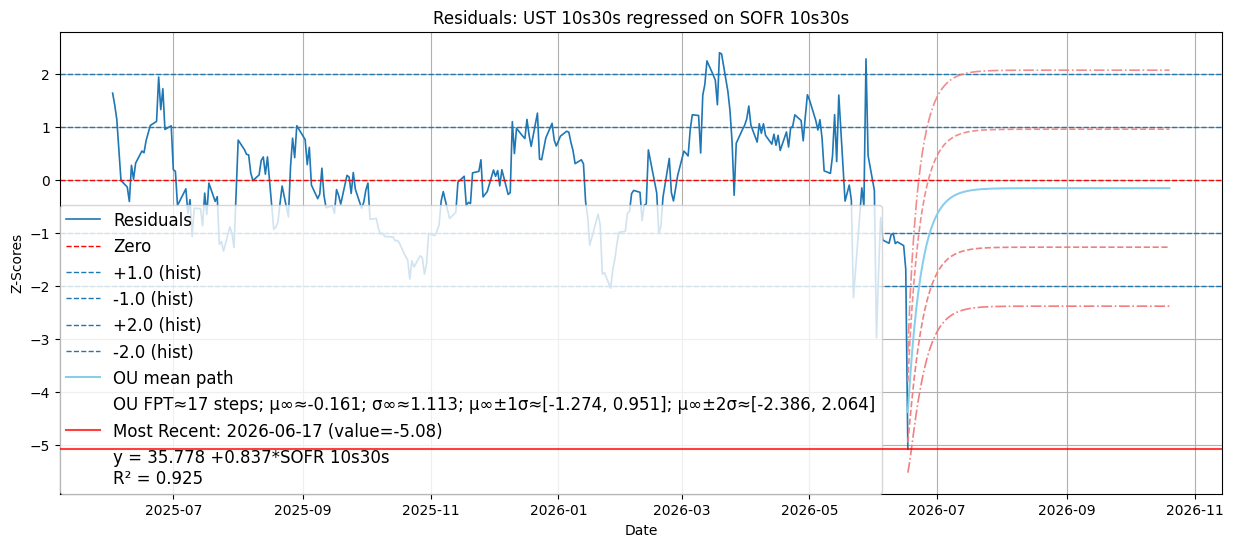

In [3]:
from RVUtils.regression import make_linear_regression_builder, rolling_beta_stability, residual_diagnostics
reg = pd.concat([ust_10s30s.rename("UST 10s30s"), sofr_10s30s.rename("SOFR 10s30s")], axis=1).dropna()
add_indep_var, fitr, pavp, prvp, prts, get_data = make_linear_regression_builder(df=reg, y_col="UST 10s30s")
add_indep_var("SOFR 10s30s")
res = fitr(model="OLS", verbose=False)
print("beta:", {k: round(float(v),3) for k,v in res.params.items()}, " R2:", round(res.rsquared,3))
diag = residual_diagnostics(res.resid)
print("residual half-life:", round(diag["half_life"],1), "d | ADF p:", round(diag["adf_pvalue"],4))
prts(plot_zscores=True, plot_zero=True, stds=[1,2], ou_bands=True)

### Beta-stability Traffic-Light Index (TLI) for the 2s5s10s fly (gate >= 3)

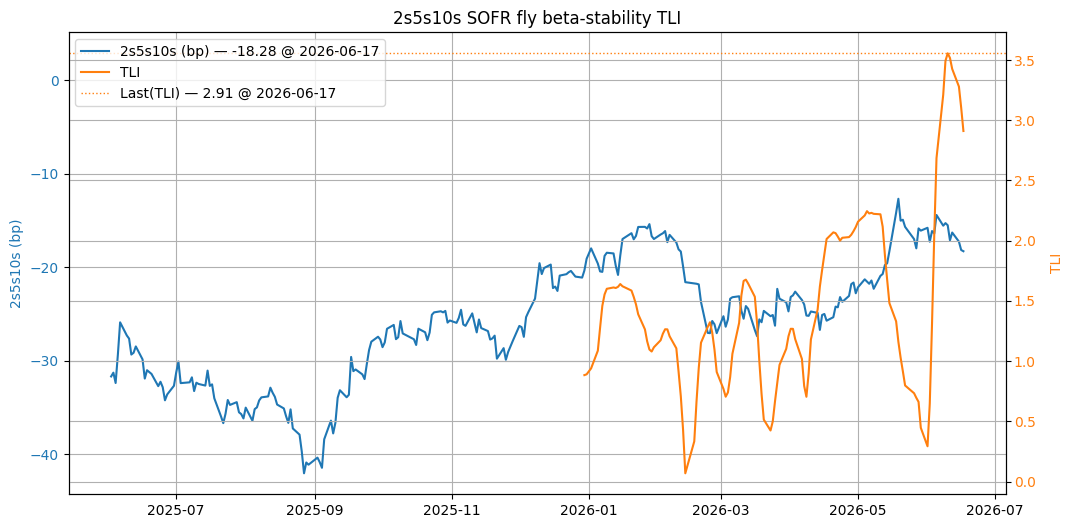

In [4]:
df_f = sofr(["2y","5y","10y"])
fly = (2*df_f["5y"] - df_f["2y"] - df_f["10y"]) * 100
drivers = pd.concat([df_f["5y"].rename("level"), ((df_f["10y"]-df_f["2y"])*100).rename("slope")], axis=1)
tli = rolling_beta_stability(fly, drivers, window_beta=63, window_vol=21, window_z=63)
plot, fig, ax, ax2, legend = make_secondary_axis_plot(engine="matplotlib", title="2s5s10s SOFR fly beta-stability TLI")
plot(fly.rename("2s5s10s (bp)"), which="left")
plot(tli["TLI"].rename("TLI"), which="right", indicators=[{"kind":"last"}])
legend(show_date=True, loc="upper left"); plt.show()

### Cointegration: 10y swap spread (UST CT10 vs SOFR 10y)

EG beta: 0.918  ADF p: 0.4729  half-life: 13.4 d
Johansen rank: 0  coint vector: [ 1.    -0.702]


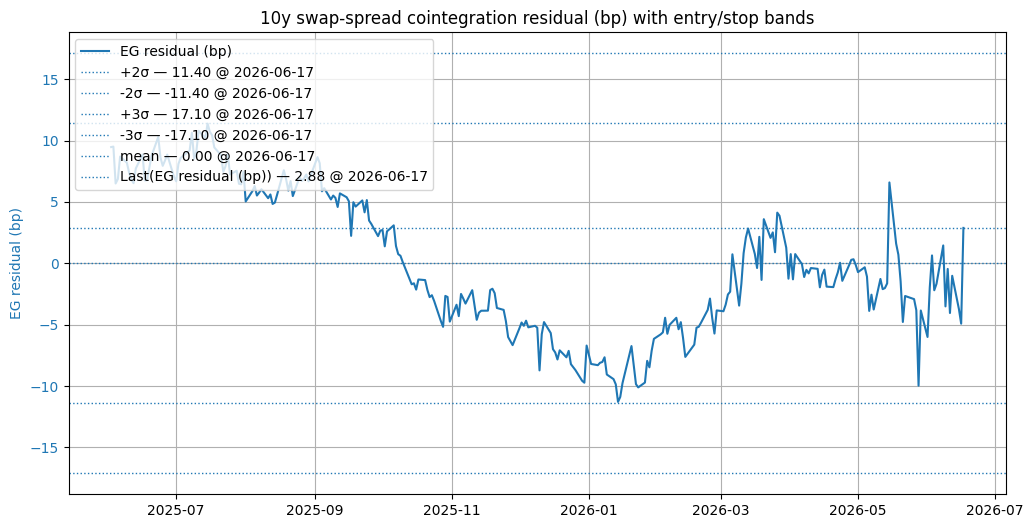

In [5]:
from RVUtils.cointegration import engle_granger, johansen
eg = engle_granger(df_u["CT10"], df_s["10y"])
print("EG beta:", round(eg["beta"],3), " ADF p:", round(eg["pvalue"],4), " half-life:", round(eg["half_life"],1), "d")
jo = johansen(pd.concat([df_u["CT10"].rename("CT10"), df_s["10y"].rename("SOFR10")], axis=1).dropna())
print("Johansen rank:", jo["rank"], " coint vector:", np.round(jo["coint_vector"],3))
sp = eg["spread"] * 100
plot, fig, ax, ax2, legend = make_secondary_axis_plot(engine="matplotlib", title="10y swap-spread cointegration residual (bp) with entry/stop bands")
plot(sp.rename("EG residual (bp)"), which="left", indicators=[{"kind":"zbands","entry":2,"stop":3}, {"kind":"last"}])
legend(show_date=True, loc="upper left"); plt.show()

### OU ex-ante Sharpe on the cointegration residual

In [6]:
from RVUtils.signal_backtest import make_signal_backtest_builder
sb = make_signal_backtest_builder(eg["spread"])
forecast, zsig, position, pnl, stats_fn, ex_ante, fpt, gate, getd = sb
print("OU ex-ante Sharpe (21d):", round(ex_ante(horizon=21), 2))

OU ex-ante Sharpe (21d): -1.52
